In [70]:
import datetime
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

In [71]:
data = pd.read_csv('Preprocessed/Preprocessed_data.csv')
data.head()

,Date,Comp,Day,Venue,Result,Team,Opponent,xG,xGA,Poss,...,O_Mis,O_Dis,O_PrgR,O_CrdY,O_CrdR,O_Int.1,O_TklW.1,O_PKwon,O_OG,O_Lost.1
0,2017-08-12,Premier League,Sat,Away,W,Manchester City,Brighton,1.9,0.3,77.0,...,2.0,8.0,4.0,0.0,0.0,12.0,8.0,0.0,1.0,13.0
1,2017-08-21,Premier League,Mon,Home,D,Manchester City,Everton,1.1,0.6,64.0,...,10.0,7.0,13.0,4.0,1.0,16.0,12.0,0.0,0.0,22.0
2,2017-08-26,Premier League,Sat,Away,W,Manchester City,Bournemouth,1.4,0.5,70.0,...,8.0,9.0,17.0,5.0,0.0,12.0,13.0,0.0,0.0,23.0
3,2017-09-09,Premier League,Sat,Home,W,Manchester City,Liverpool,2.4,0.7,66.0,...,9.0,9.0,19.0,2.0,1.0,18.0,12.0,0.0,0.0,9.0
4,2017-09-13,Champions Lg,Wed,Away,W,Manchester City,nl Feyenoord,1.3,0.3,71.0,...,7.0,7.0,12.0,4.0,0.0,13.0,9.0,0.0,0.0,14.0


In [72]:
data = pd.get_dummies(data, columns=['Venue', 'Day', 'Team', 'Opponent', 'Captain', 'Formation', 'Referee', 'Comp'], dtype=int)
encoded_names = data.columns.tolist()
# encoded_names

In [73]:
data['FTR'] = np.where(data['Result'] == 'W', 1, np.where(
    data['Result'] == 'D', 0, np.where(data['Result'] == 'L', 2, np.nan)))
data.drop('Result', axis=1, inplace=True)

In [74]:
data['Date'] = pd.to_datetime(data['Date'])


def get_weights(data):
    now = datetime.datetime.now()
    weight = 1.0 / (1 + (now - data['Date']).dt.days / 365)
    return weight


data['weight'] = get_weights(data)
data.head()

,Date,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,...,Comp_Ligue 1,Comp_Premier League,Comp_Primeira Liga,Comp_Primera Div,Comp_Pro League A,Comp_Serie A,Comp_Série A,Comp_WSL,FTR,weight
0,2017-08-12,1.9,0.3,77.0,30415.0,4.0,0.07,0.25,19.5,0.0,...,0,1,0,0,0,0,0,0,1.0,0.132151
1,2017-08-21,1.1,0.6,64.0,49108.0,6.0,0.05,0.17,20.0,0.0,...,0,1,0,0,0,0,0,0,0.0,0.132583
2,2017-08-26,1.4,0.5,70.0,10419.0,8.0,0.11,0.25,16.2,0.0,...,0,1,0,0,0,0,0,0,1.0,0.132824
3,2017-09-09,2.4,0.7,66.0,54172.0,10.0,0.38,0.50,14.0,0.0,...,0,1,0,0,0,0,0,0,1.0,0.133504
4,2017-09-13,1.3,0.3,71.0,43500.0,7.0,0.36,0.57,14.4,0.0,...,0,0,0,0,0,0,0,0,1.0,0.133700


In [75]:
means = data.mean()
data.fillna(means, inplace=True)
data.dropna(inplace=True)

ss = MinMaxScaler()
data.iloc[:,1:-2] = ss.fit_transform(data.iloc[:,1:-2])

In [76]:
x_train, x_test, y_train, y_test = train_test_split(data.drop(['FTR', 'Date'], axis=1), data['FTR'], random_state=42, test_size=0.2)

In [87]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acs = accuracy_score(y_test, y_pred)

c:\Users\moomad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [88]:
acs

0.953307392996109

In [89]:
conma = confusion_matrix(y_test, y_pred)
conma

array([[ 530,   31,   19],
       [  20, 1251,    5],
       [  31,    2,  424]], dtype=int64)

In [90]:
clf = classification_report(y_test, y_pred)
print(clf)

              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91       580
         1.0       0.97      0.98      0.98      1276
         2.0       0.95      0.93      0.94       457

    accuracy                           0.95      2313
   macro avg       0.94      0.94      0.94      2313
weighted avg       0.95      0.95      0.95      2313



Deep Learning Model

In [77]:
x_train

,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,npxG/Sh,...,Comp_Libertadores,Comp_Ligue 1,Comp_Premier League,Comp_Primeira Liga,Comp_Primera Div,Comp_Pro League A,Comp_Serie A,Comp_Série A,Comp_WSL,weight
6760,0.175824,0.050000,0.353846,0.056250,0.272727,0.09,0.33,0.431373,0.0,0.139535,...,0,1,0,0,0,0,0,0,0,0.183602
7850,0.549451,0.033333,0.692308,0.091243,0.545455,0.17,0.42,0.280112,0.0,0.418605,...,0,0,0,0,0,0,0,0,0,0.183879
7212,0.010989,0.216667,0.630769,0.094502,0.409091,0.21,0.33,0.243697,0.0,0.325581,...,0,0,0,0,0,0,0,0,0,0.196978
8971,0.021978,0.066667,0.215385,0.139404,0.045455,0.00,0.00,0.302521,0.0,0.116279,...,0,0,0,0,0,0,0,0,0,0.236399
1994,0.131868,0.200000,0.569231,0.271105,0.090909,0.06,0.50,0.313725,0.0,0.139535,...,0,0,0,0,0,0,0,0,0,0.146234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,0.175824,0.333333,0.338462,0.192607,0.227273,0.08,0.20,0.364146,0.0,0.279070,...,0,0,0,0,0,0,0,0,0,0.549699
21575,0.373626,0.066667,0.692308,0.070279,0.409091,0.08,0.22,0.338936,0.0,0.279070,...,0,1,0,0,0,0,0,0,0,0.877404
5390,0.087912,0.533333,0.692308,0.139404,0.090909,0.09,0.50,0.464986,0.0,0.139535,...,0,0,1,0,0,0,0,0,0,0.212952
860,0.076923,0.183333,0.523077,0.076953,0.136364,0.00,0.00,0.282913,0.0,0.139535,...,0,0,0,0,0,0,1,0,0,0.144669


In [ ]:
weights = x_train['weight']
x_train.drop('weight', axis = 1)
x_test.drop('weight', axis = 1)

In [79]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
x_train

In [81]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [82]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [83]:
history = model.fit(x_train, y_train, epochs=30,
                    batch_size=32, sample_weight=weights, validation_data=(x_test, y_test))

Epoch 1/30
579/579 [==============================] - 5s 7ms/step - loss: 0.2198 - accuracy: 0.6987 - val_loss: 0.3427 - val_accuracy: 0.8852
Epoch 2/30
579/579 [==============================] - 3s 5ms/step - loss: 0.1274 - accuracy: 0.8546 - val_loss: 0.2646 - val_accuracy: 0.9027
Epoch 3/30
579/579 [==============================] - 3s 5ms/step - loss: 0.0992 - accuracy: 0.8954 - val_loss: 0.2336 - val_accuracy: 0.9150
Epoch 4/30
579/579 [==============================] - 3s 5ms/step - loss: 0.0873 - accuracy: 0.9081 - val_loss: 0.2233 - val_accuracy: 0.9252
Epoch 5/30
579/579 [==============================] - 3s 5ms/step - loss: 0.0773 - accuracy: 0.9176 - val_loss: 0.2222 - val_accuracy: 0.9222
Epoch 6/30
579/579 [==============================] - 3s 5ms/step - loss: 0.0680 - accuracy: 0.9278 - val_loss: 0.2231 - val_accuracy: 0.9135
Epoch 7/30
579/579 [==============================] - 3s 6ms/step - loss: 0.0606 - accuracy: 0.9365 - val_loss: 0.2081 - val_accuracy: 0.9256
Epoch 

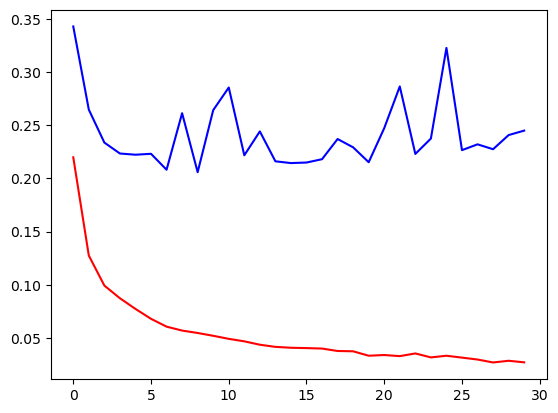

In [85]:
plt.plot(history.history['loss'], color='red', label='Train Data')
plt.plot(history.history['val_loss'], color='blue', label='Validation Data')

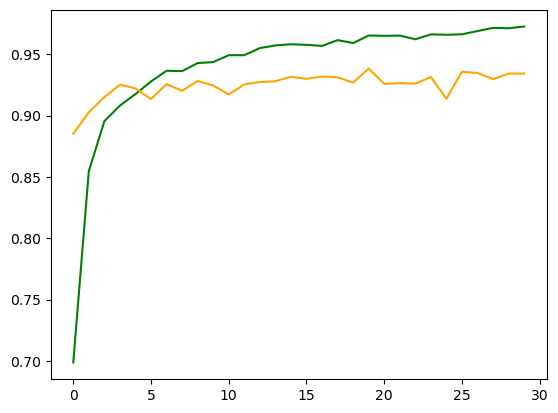

In [86]:
plt.plot(history.history['accuracy'], color='green', label='Train Data')
plt.plot(history.history['val_accuracy'], color='orange', label='Validation Data')

In [20]:
# model.save('FinalData.h5', 'wb')

In [ ]:
nl = data.columns.to_list()

In [ ]:
import seaborn as sns
for i in data.columns.to_list():
    print(f'Plot for {i} at below' )
    sns.histplot(data[i])
    plt.show()